<img src="../logo_UNSAM.jpg" align="right" width="150" /> 

# Análisis y Procesamiento de Señales
## Trabajo Semanal Nº 3: Análisis de Fourier
**Autor:** Federico Pieri  
**Institución:** Escuela de Ciencia y Tecnología — Universidad Nacional de San Martín (UNSAM)

---

## Introducción
La Transformada Rápida de Fourier (FFT) es una herramienta que se utiliza, entre otras aplicaciones, para calcular el espectro de potencia de una señal determinada. Esta operación presenta un fenómeno particular, conocido como *desparramo espectral* o *spectral leakage*, que ocurre cuando se analizan frecuencias cuyo período no entra un número entero de veces dentro de la ventana de muestreo. 

En este trabajo realizaremos la experiencia de calcular las densidades espectrales de potencia de tres funciones senoidales. La primera tendrá una frecuencia exacta $f_0$ correspondiente al *bin* $k_0 = \frac{N}{4}$, mientras que a las dos siguientes se les aplicará un desplazamiento (desintonía) de $0.25 \cdot \Delta f$ y $0.5 \cdot \Delta f$ respectivamente. Por último, analizaremos qué ocurre con los espectros resultantes si, en lugar de utilizar únicamente la ventana rectangular implícita, se implementa la técnica de *zero padding*.


--- 
## 1. Señales con ventana implícita:
En este apartado se presentan los gráficos correspondientes a las tres señales mencionadas, procesadas con la ventana rectangular implícita de la DFT. 

En el espectro de la señal con frecuencia exacta $f_0$, se observa un único pico bien definido, similar a una delta de Dirac. Esto es el resultado teórico esperable para la transformada de una función senoidal pura cuando su período encaja un número entero de veces en la ventana de análisis. 

Por el contrario, en los espectros de las señales que presentan desintonía, se evidencia que el pico principal no alcanza la potencia teórica esperada ($1\text{ W} = 0\text{ dB}$) y aparece contenido de potencia en frecuencias donde teóricamente no debería haberlo. Este fenómeno muestra claramente el concepto de **desparramo espectral**: la energía que falta en el lóbulo principal se distribuye o "desparrama" a lo largo del resto de los *bins* del espectro.

Además, se puede observar que a mayor desintonía, el efecto del desparramo espectral resulta más severo. En la señal con el mayor corrimiento en frecuencia, esto se manifiesta visualmente con un pico principal de menor amplitud y un incremento general en el nivel de piso, el cual se sitúa aproximadamente en $-50\text{ dB}$.

Para comprender el origen matemático del desparramo espectral, es necesario analizar el proceso de ventaneo (*windowing*) desde la perspectiva de sus transformadas.

**Operación en el dominio del tiempo**
Tomar un bloque finito de $N$ muestras de una señal senoidal para calcular su DFT equivale, matemáticamente, a tomar una señal senoidal de duración infinita y multiplicarla por una ventana rectangular.
$$x_w[n] = x[n] \cdot w[n]$$

**Operación en el dominio de la frecuencia**
Debido a las propiedades de la Transformada de Fourier, la multiplicación en el dominio temporal se transforma en una operación de convolución en el dominio de la frecuencia:
$$X_w(f) = X(f) * W(f)$$

Analizando las transformadas individuales:
*   **Transformada del seno puro ($X(f)$):** Es un espectro ideal compuesto únicamente por dos deltas de Dirac ubicadas exactamente en las frecuencias $\pm f_0$.
*   **Transformada de la ventana rectangular ($W(f)$):** Corresponde a una función tipo $\text{sinc}$, caracterizada por un lóbulo principal ancho y múltiples lóbulos laterales (armónicos) que decaen progresivamente.

Al efectuar la convolución de las deltas con la función $\text{sinc}$, esta última se desplaza centrandose en las frecuencias $\pm f_0$. Por lo tanto, el espectro continuo resultante de nuestra señal finita siempre tiene forma de $\text{sinc}$.

El desparramo ocurre dependiendo de cómo la DFT "muestrea" este espectro continuo:
*   **Señal sin desintonía:** Las frecuencias de los *bins* de la DFT caen exactamente sobre el pico máximo del lóbulo principal y, fundamentalmente, sobre los **cruces por cero** de los lóbulos laterales de la $\text{sinc}$. El resultado visual es un único punto con energía, aparentando una delta perfecta.
*   **Señal con desintonía:** Cuando la frecuencia cae entre dos *bins*, la DFT toma muestras de la función $\text{sinc}$ desplazada en puntos donde los lóbulos laterales **no son cero**. Toda esa energía de las colas de la función $\text{sinc}$ es lo que visualizamos como desparramo a lo largo de todo el espectro.

Por último, mediante el **Teorema de Parseval**, se calculó la potencia total de cada una de estas señales utilizando su espectro completo. 

Si bien en los casos con desintonía la potencia concentrada en el lóbulo principal es visiblemente menor a la esperada, se puede comprobar que la sumatoria de la potencia a lo largo de todo el espectro arroja el valor correcto ($1\text{ W}$). Esto demuestra de forma práctica un concepto fundamental: el desparramo espectral no altera ni disminuye la energía total de la señal analizada, sino que simplemente la redistribuye hacia el resto de los *bins* de frecuencia.

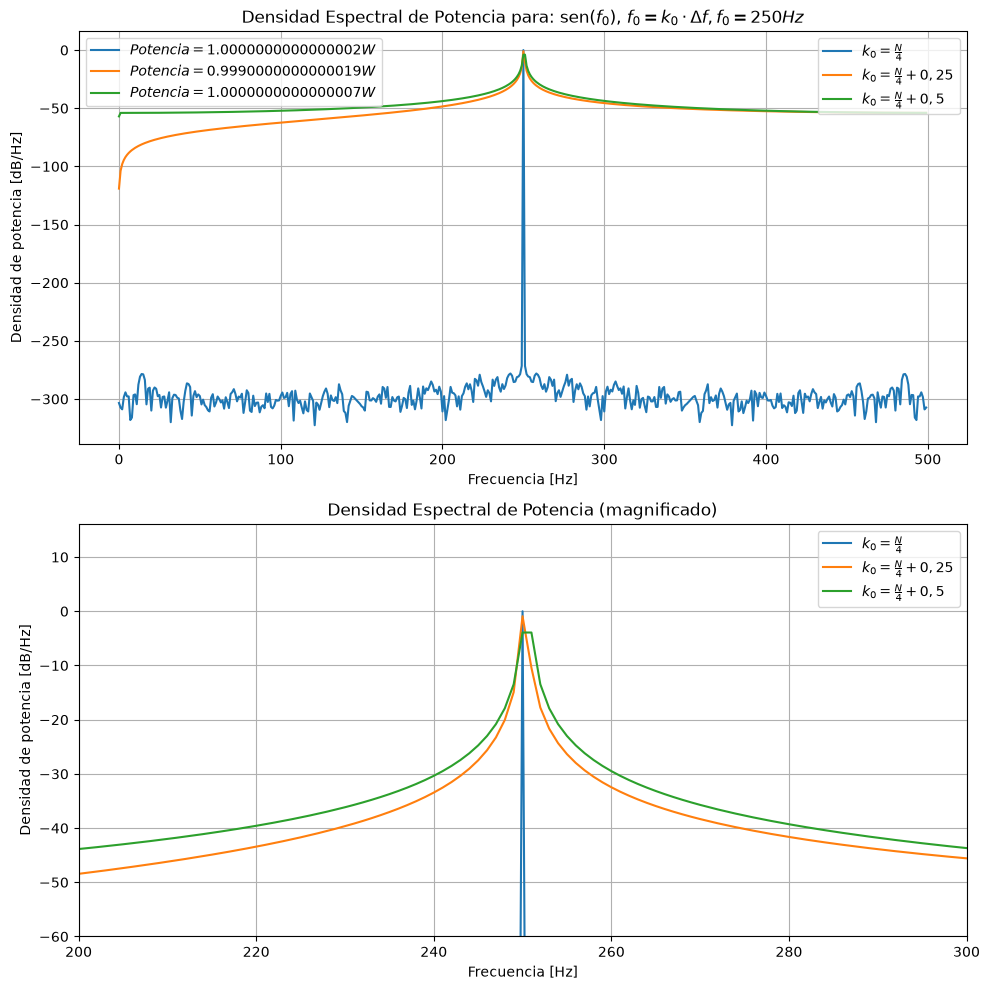

In [17]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
from IPython.display import display, HTML

display(HTML("""
<style>
/* Centrado para JupyterLab y Jupyter Notebook 7+ */
.jp-RenderedImage {
    display: flex;
    justify-content: center;
}
.jp-OutputArea-child {
    display: flex;
    justify-content: center;
}

/* Centrado para Jupyter Notebook Clásico (por si acaso) */
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
"""))
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen
import numpy as np
import matplotlib.pyplot as plt


#%%   ------------------ Definiciones

N = 1000
fs = 1000
Vfs = 2
k0 = N/4
muestras_tiempo = 10 


#%%   ------------------- Genero funciones 

f0 = (k0)*fs/N
tt , xx0 = gen.senoidal(pot=1,ff=f0,fs=fs,nn =N )

f1=(k0+0.25)*fs/N
_ , xx1 = gen.senoidal(pot=1,ff=f1,fs=fs,nn =N )

f2=(k0+0.5)*fs/N
_ , xx2 = gen.senoidal(pot=1,ff=f2,fs=fs,nn =N )

#%% ------------------- Transformadas

df = fs/N

X0 = 1/N * np.fft.fft(xx0)         # FFT normalizada
p_X0 = np.abs(X0)**2               # Paso a potencia 
p_X0[1:] = p_X0[1:] * 2            # Multiplico por 2 excepto la primer muestra (nivel de dc)
p_X0 = p_X0 / df                   # Calculo densidad de potencia espectral
X0_db = 10 * np.log10(p_X0)        # Paso a db


X1 = 1/N * np.fft.fft(xx1)         # FFT normalizada
p_X1 = np.abs(X1)**2               # Paso a potencia 
p_X1[1:] = p_X1[1:] * 2            # Multiplico por 2 excepto la primer muestra (nivel de dc)
p_X1 = p_X1 / df                   # Calculo densidad de potencia espectral
X1_db = 10 * np.log10(p_X1)        # Paso a db

X2 = 1/N * np.fft.fft(xx2)         # FFT normalizada
p_X2 = np.abs(X2)**2               # Paso a potencia 
p_X2[1:] = p_X2[1:] * 2            # Multiplico por 2 excepto la primer muestra (nivel de dc)
p_X2 = p_X2 / df                   # Calculo densidad de potencia espectral
X2_db = 10 * np.log10(p_X2)        # Paso a db

frec = tt * (fs / N)
frec = frec[:(N // 2)]

pot_parseval1 = sum((np.abs(X0)**2))
pot_parseval2 = sum((np.abs(X1)**2))
pot_parseval3 = sum((np.abs(X2)**2))

tt = tt /fs * 1000   # Tiempo en ms

#%%  Ploteos
# =====================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# # Subplot 1: Señales de amplitud en el tiempo
sen1, = ax1.plot(frec, X0_db[:(N // 2)])
sen2, = ax1.plot(frec, X1_db[:(N // 2)])
sen3, = ax1.plot(frec, X2_db[:(N // 2)])
lineas = [sen1, sen2, sen3]
etiquetas_k = [r'$k_0 = \frac{N}{4}$', r'$k_0 = \frac{N}{4}+0,25$', r'$k_0 = \frac{N}{4}+0,5$']
leyenda_derecha = ax1.legend(lineas, etiquetas_k, loc='upper right')
ax1.add_artist(leyenda_derecha) 
etiquetas_pot = [rf'$Potencia = {pot_parseval1:}W$', rf'$Potencia = {pot_parseval2:}W$', rf'$Potencia = {pot_parseval3:}W$']
ax1.legend(lineas, etiquetas_pot, loc='upper left')
ax1.set_title(r'Densidad Espectral de Potencia para: sen($f_0$), $f_0 = k_0 \cdot \Delta f, f_0 = 250Hz$')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('Densidad de potencia [dB/Hz]')

ax1.grid(True)

# Subplot 2: Espectros de potencia en frecuencia
ax2.plot(frec, X0_db[:(N // 2)], label=r'$k_0 = \frac{N}{4}$')
ax2.plot(frec, X1_db[:(N // 2)], label=r'$k_0 = \frac{N}{4}+0,25$')
ax2.plot(frec, X2_db[:(N // 2)], label=r'$k_0 = \frac{N}{4}+0,5$')
ax2.set_title(r'Densidad Espectral de Potencia (magnificado)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Densidad de potencia [dB/Hz]')
ax2.set_ylim(-60)
ax2.set_xlim([200,300])
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()


## 2. Zero padding
En este punto se aplica la técnica de *zero padding*, la cual consiste en extender la cantidad de muestras agregando ceros al final de la señal original. Esto incrementa la longitud total de la secuencia, multiplicando la cantidad original de muestras $N$ por un factor $K$ y rellenando ese nuevo espacio con ceros.

Este proceso no aporta información nueva a la señal, sino que provoca un aumento en la densidad de puntos evaluados sobre el espectro (lo que se puede ver como un aumento "ficticio" de la resolución espectral). Al disponer de más muestras en el dominio de la frecuencia, la DFT actúa como un interpolador, permitiendo visualizar la forma de la función $\text{sinc}$ que resulta de la convolución mencionada anteriormente.

En el gráfico magnificado se pueden apreciar claramente las funciones $\text{sinc}$ completas. En ellas se observa que el lóbulo principal alcanza correctamente la potencia teórica de $0\text{ dB}$ para cada frecuencia central $f_0$, y se hacen visibles los lóbulos secundarios. El primero de estos lóbulos laterales presenta un nivel de atenuación de aproximadamente $-13\text{ dB}$, el cual es el valor esperado para una ventana rectangular.

Además, de igual manera que en el análisis anterior, se calculó la potencia total de estas secuencias extendidas empleando el Teorema de Parseval. Con esto se comprueba que, a pesar del agregado de ceros y del cambio en la representación visual de la densidad espectral, la energía total de la señal original se conserva, arrojando nuevamente un valor exacto de $1\text{ W}$.



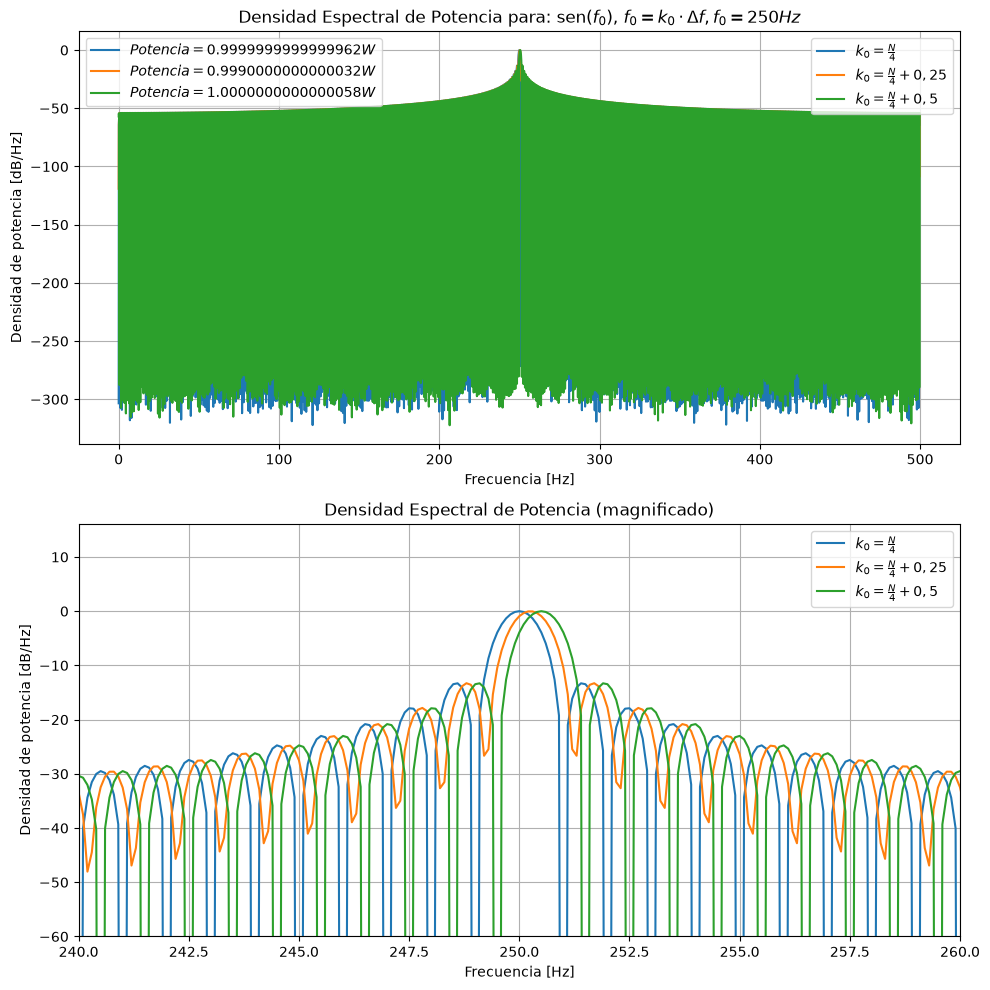

In [24]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
from IPython.display import display, HTML

display(HTML("""
<style>
/* Centrado para JupyterLab y Jupyter Notebook 7+ */
.jp-RenderedImage {
    display: flex;
    justify-content: center;
}
.jp-OutputArea-child {
    display: flex;
    justify-content: center;
}

/* Centrado para Jupyter Notebook Clásico (por si acaso) */
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
"""))
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen
import numpy as np
import matplotlib.pyplot as plt


#%%   ------------------ Definiciones

N = 1000
fs = 1000
Vfs = 2
k0 = N/4
muestras_tiempo = 10 
factor = 10

#%%   ------------------- Genero funciones 

f0 = (k0)*fs/N
tt , xx0 = gen.senoidal(pot=1,ff=f0,fs=fs,nn =N )

f1=(k0+0.25)*fs/N
_ , xx1 = gen.senoidal(pot=1,ff=f1,fs=fs,nn =N )

f2=(k0+0.5)*fs/N
_ , xx2 = gen.senoidal(pot=1,ff=f2,fs=fs,nn =N )

#%% ------------------- Padeo con 0

xx0 ,tt =gen.zero_padding(xx0)
xx1 ,_ =gen.zero_padding(xx1)
xx2 ,_ =gen.zero_padding(xx2)

N2 = N*factor
frec = np.arange(int(N2 / 2)) * (fs / N2)

#%% ------------------- Transformadas

df = fs/N

X0 = 1/N * np.fft.fft(xx0)         # FFT normalizada
p_X0 = np.abs(X0)**2               # Paso a potencia 
p_X0[1:] = p_X0[1:] * 2            # Multiplico por 2 excepto la primer muestra (nivel de dc)
p_X0 = p_X0 / df                   # Calculo densidad de potencia espectral
X0_db = 10 * np.log10(p_X0)        # Paso a db


X1 = 1/N * np.fft.fft(xx1)         # FFT normalizada
p_X1 = np.abs(X1)**2               # Paso a potencia 
p_X1[1:] = p_X1[1:] * 2            # Multiplico por 2 excepto la primer muestra (nivel de dc)
p_X1 = p_X1 / df                   # Calculo densidad de potencia espectral
X1_db = 10 * np.log10(p_X1)        # Paso a db

X2 = 1/N * np.fft.fft(xx2)         # FFT normalizada
p_X2 = np.abs(X2)**2               # Paso a potencia 
p_X2[1:] = p_X2[1:] * 2            # Multiplico por 2 excepto la primer muestra (nivel de dc)
p_X2 = p_X2 / df                   # Calculo densidad de potencia espectral
X2_db = 10 * np.log10(p_X2)        # Paso a db

frec = tt * (fs / N2)
frec = frec[:(N2 // 2)]

pot_parseval1 = sum((np.abs(X0)**2))/factor
pot_parseval2 = sum((np.abs(X1)**2))/factor
pot_parseval3 = sum((np.abs(X2)**2))/factor

tt = tt /fs * 1000   # Tiempo en ms

#%%  Ploteos
# =====================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# # Subplot 1: Señales de amplitud en el tiempo
sen1, = ax1.plot(frec, X0_db[:(N2 // 2)])
sen2, = ax1.plot(frec, X1_db[:(N2 // 2)])
sen3, = ax1.plot(frec, X2_db[:(N2 // 2)])
lineas = [sen1, sen2, sen3]
etiquetas_k = [r'$k_0 = \frac{N}{4}$', r'$k_0 = \frac{N}{4}+0,25$', r'$k_0 = \frac{N}{4}+0,5$']
leyenda_derecha = ax1.legend(lineas, etiquetas_k, loc='upper right')
ax1.add_artist(leyenda_derecha) 
etiquetas_pot = [rf'$Potencia = {pot_parseval1:}W$', rf'$Potencia = {pot_parseval2:}W$', rf'$Potencia = {pot_parseval3:}W$']
ax1.legend(lineas, etiquetas_pot, loc='upper left')
ax1.set_title(r'Densidad Espectral de Potencia para: sen($f_0$), $f_0 = k_0 \cdot \Delta f, f_0 = 250Hz$')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('Densidad de potencia [dB/Hz]')

ax1.grid(True)

# Subplot 2: Espectros de potencia en frecuencia
ax2.plot(frec, X0_db[:(N2 // 2)], label=r'$k_0 = \frac{N}{4}$')
ax2.plot(frec, X1_db[:(N2 // 2)], label=r'$k_0 = \frac{N}{4}+0,25$')
ax2.plot(frec, X2_db[:(N2 // 2)], label=r'$k_0 = \frac{N}{4}+0,5$')
ax2.set_title(r'Densidad Espectral de Potencia (magnificado)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Densidad de potencia [dB/Hz]')
ax2.set_ylim(-60)
ax2.set_xlim([240,260])
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()

## Conclusión
Podemos decir que la implementación del *zero padding* permite visualizar de manera mucho más clara y definida la densidad espectral de potencia. Al incrementar la cantidad de puntos evaluados en el espectro, esta técnica revela la verdadera forma continua de la función resultante y permite identificar con precisión el nivel de potencia máxima de cada componente frecuencial, mitigando la atenuación visual que sufren las señales con desintonía.